In [11]:
import json
import re
import numpy as np
from typing import List
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

In [12]:
_SENTENCE_SPLIT_RE = re.compile(r'(?<!\d)\.(?!\d)')


def split_caption_sentences(captions: List[str]) -> List[List[str]]:
    return [
        [
            sentence.strip()
            for sentence in _SENTENCE_SPLIT_RE.split(caption)
            if sentence.strip()
        ]
        for caption in captions
    ]

In [14]:
with open("../data/MusicBench_train.json", "r", encoding="utf-8") as f:
    train_data = json.load(f)

main_captions = [x["main_caption"] for x in train_data]
alt_captions = [x["alt_caption"] for x in train_data]

split_main_captions = split_caption_sentences(main_captions)
split_alt_captions = split_caption_sentences(alt_captions)

In [15]:
prototypes = {
    0: [  # instrumentation / timbre
        "A guitar plays a melody",
        "The drums and bass create the groove",
        "A synth pad fills the background",
        "A female voice sings softly"
    ],

    1: [  # tempo / rhythm / meter
        "The song is 120 beats per minute",
        "The rhythm follows a 4/4 time signature",
        "The beat counts to four",
        "The groove has a syncopated rhythm"
    ],

    2: [  # harmony / key / chords
        "The chord progression is Cmaj7 to Am7",
        "The song is in A minor",
        "The harmony moves through several chords",
        "The melody resolves to the tonic"
    ],

    3: [  # genre / style
        "This is a jazz fusion piece",
        "The song is in a synth pop style",
        "This is a hip hop beat",
        "The track has an EDM production style"
    ],

    4: [  # emotion / mood
        "The music feels melancholic and emotional",
        "The atmosphere is dark and tense",
        "The piece sounds joyful and uplifting",
        "The mood is sad and reflective"
    ],

    5: [  # scene / imagery / context
        "This would fit a movie scene",
        "The song sounds like a game soundtrack",
        "This could play during a dramatic battle",
        "This fits a romantic scene in a film"
    ]
}

In [16]:
embedding_model = SentenceTransformer("BAAI/bge-base-en-v1.5")

No sentence-transformers model found with name BAAI/bge-base-en-v1.5. Creating a new one with mean pooling.


In [17]:
prototype_embeddings = {}

for label, prototype_sentences in prototypes.items():
    emb = embedding_model.encode(prototype_sentences)
    prototype_embeddings[label] = np.mean(emb, axis=0)

In [18]:
def classify_caption_sentences(split_captions):
    classified = []

    for caption in tqdm(split_captions, desc="Classifying captions"):
        caption_labels = []

        if len(caption) == 0:
            classified.append([])
            continue

        sentence_embeddings = embedding_model.encode(caption)

        for sentence_emb in sentence_embeddings:
            similarities = {}

            for label, proto_emb in prototype_embeddings.items():
                sim = cosine_similarity(
                    sentence_emb.reshape(1, -1),
                    proto_emb.reshape(1, -1)
                )[0][0]

                similarities[label] = sim

            best_label = max(similarities, key=similarities.get)
            caption_labels.append(best_label)

        classified.append(caption_labels)

    return classified

In [19]:
main_caption_classes = classify_caption_sentences(split_main_captions)
alt_caption_classes = classify_caption_sentences(split_alt_captions)

Classifying captions: 100%|██████████| 47492/47492 [2:31:20<00:00,  5.23it/s]  


In [20]:
with open("main_caption_classes_berttopic.json", "w") as f:
    json.dump(main_caption_classes, f)

with open("alt_caption_classes_berttopic.json", "w") as f:
    json.dump(alt_caption_classes, f)

print("Saved.")

Saved.


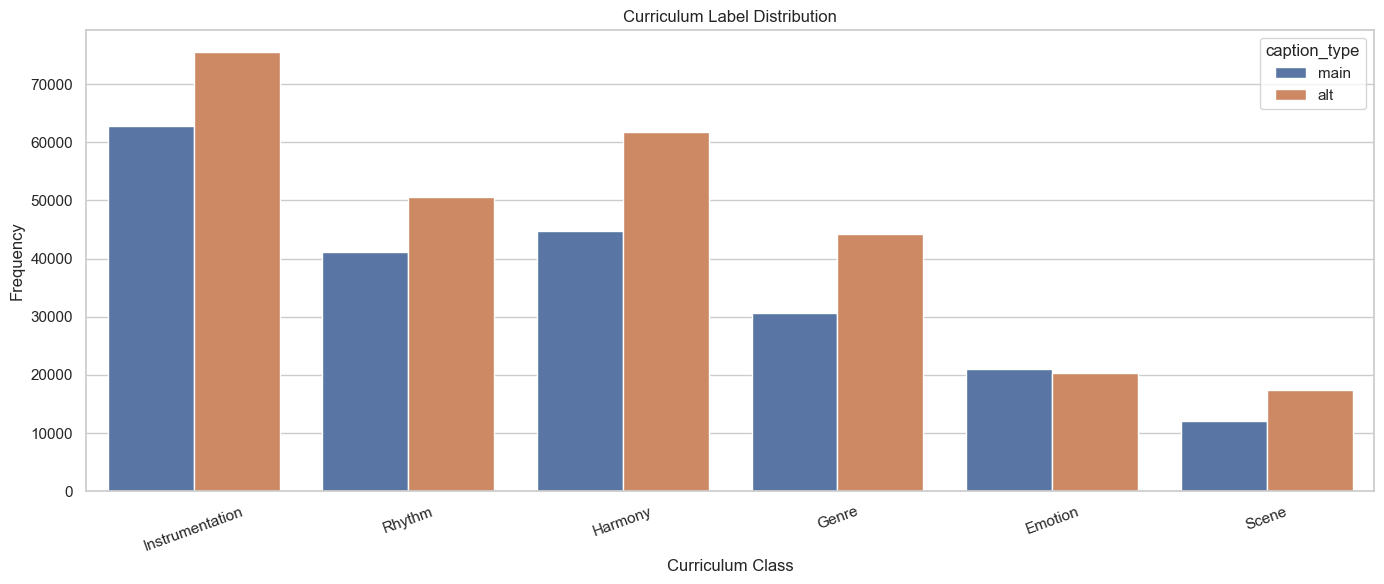

In [21]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")

# flatten labels
main_labels = [label for caption in main_caption_classes for label in caption]
alt_labels = [label for caption in alt_caption_classes for label in caption]

# count
main_counts = Counter(main_labels)
alt_counts = Counter(alt_labels)

# build dataframe
combined = []

for label in range(6):
    combined.append({
        "label": label,
        "caption_type": "main",
        "count": main_counts.get(label, 0)
    })

    combined.append({
        "label": label,
        "caption_type": "alt",
        "count": alt_counts.get(label, 0)
    })

combined_df = pd.DataFrame(combined)

# plot
plt.figure(figsize=(14, 6))

sns.barplot(
    data=combined_df,
    x="label",
    y="count",
    hue="caption_type"
)

plt.xticks(
    [0, 1, 2, 3, 4, 5],
    [
        "Instrumentation",
        "Rhythm",
        "Harmony",
        "Genre",
        "Emotion",
        "Scene"
    ],
    rotation=20
)

plt.title("Curriculum Label Distribution")
plt.xlabel("Curriculum Class")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

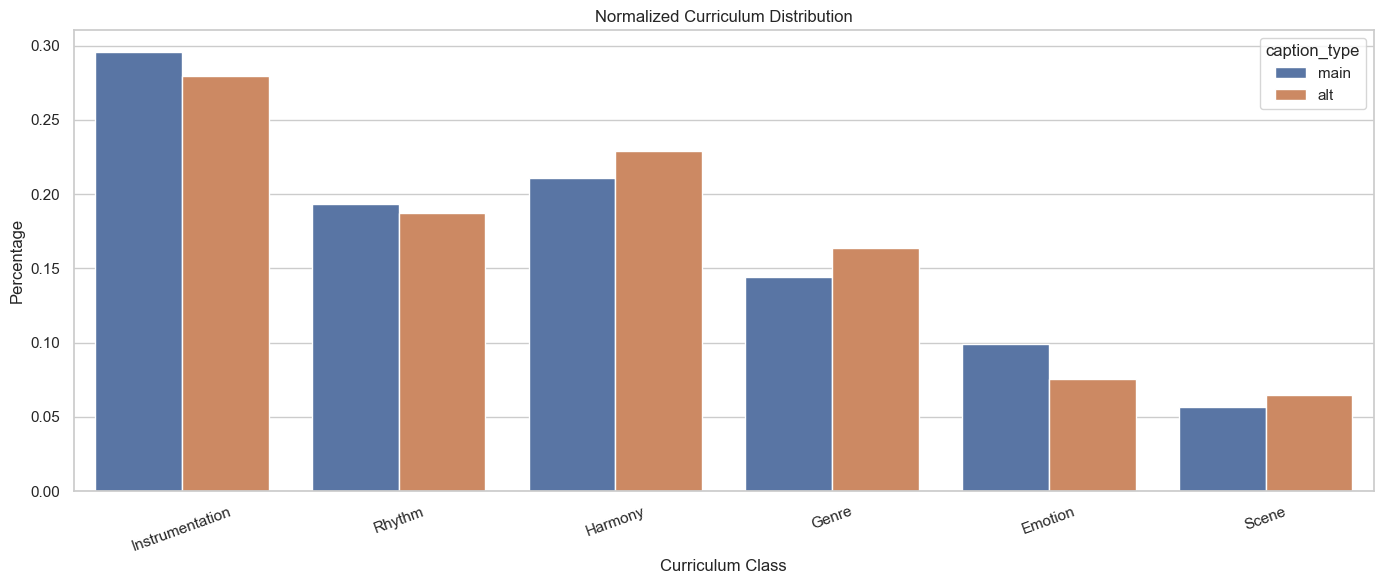

In [22]:
main_total = sum(main_counts.values())
alt_total = sum(alt_counts.values())

main_percent = {
    k: v / main_total for k, v in main_counts.items()
}

alt_percent = {
    k: v / alt_total for k, v in alt_counts.items()
}

percent_data = []

for label in range(6):
    percent_data.append({
        "label": label,
        "caption_type": "main",
        "percentage": main_percent.get(label, 0)
    })

    percent_data.append({
        "label": label,
        "caption_type": "alt",
        "percentage": alt_percent.get(label, 0)
    })

percent_df = pd.DataFrame(percent_data)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=percent_df,
    x="label",
    y="percentage",
    hue="caption_type"
)

plt.xticks(
    [0, 1, 2, 3, 4, 5],
    [
        "Instrumentation",
        "Rhythm",
        "Harmony",
        "Genre",
        "Emotion",
        "Scene"
    ],
    rotation=20
)

plt.title("Normalized Curriculum Distribution")
plt.xlabel("Curriculum Class")
plt.ylabel("Percentage")
plt.tight_layout()
plt.show()

In [23]:
from collections import defaultdict
import random

label_names = {
    0: "Instrumentation and timbre",
    1: "Tempo rhythm beat meter",
    2: "Key chords harmony progression",
    3: "Genre style production",
    4: "Emotion mood feeling",
    5: "Scene imagery context"
}

main_examples = defaultdict(list)
alt_examples = defaultdict(list)

for caption_sentences, caption_labels in zip(split_main_captions, main_caption_classes):
    for sentence, label in zip(caption_sentences, caption_labels):
        main_examples[label].append(sentence)

for caption_sentences, caption_labels in zip(split_alt_captions, alt_caption_classes):
    for sentence, label in zip(caption_sentences, caption_labels):
        alt_examples[label].append(sentence)

for label in range(6):
    print("=" * 60)
    print(f"LABEL {label}: {label_names[label]}")

    print("\nMAIN CAPTION EXAMPLES:")
    if len(main_examples[label]) == 0:
        print("(none)")
    else:
        for example in random.sample(
            main_examples[label],
            min(10, len(main_examples[label]))
        ):
            print("-", example)

    print("\nALT CAPTION EXAMPLES:")
    if len(alt_examples[label]) == 0:
        print("(none)")
    else:
        for example in random.sample(
            alt_examples[label],
            min(10, len(alt_examples[label]))
        ):
            print("-", example)

    print()

LABEL 0: Instrumentation and timbre

MAIN CAPTION EXAMPLES:
- It sounds loud, dull, messy and muffled, since the frequencies are clashing
- This audio contains someone playing a modern piece of music on an acoustic piano
- This is a pop/soft rock piece with a female vocalist singing melodically over a slow, lighthearted atmosphere
- During an amateur recording, a fast-paced melody is being played, running up and down a scale, potentially during soundcheck with a band
- A high pitched long note is playing along with other synthesizer pad sounds to create a bizarre and  mildly creepy atmosphere
- This creepy and unsettling jam was created using a homemade theremin instrument, which produces irritatingly high-pitched sounds
- Adding to the tension, there are synth strings playing a dissonant harmony while a marimba hit is played with a lot of reverb
- The chaotic and animated composition is punctuated with the sound of water or bubbles and synthesised arrangements with beeps towards the e